In [ ]:
import pandas as pd
from sklearn import metrics
from sklearn import preprocessing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
import multiprocessing
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, RepeatedKFold
from sklearn.preprocessing import LabelEncoder

In [ ]:
# Ruta al archivo CSV en Google Drive
file_path = '/content/drive/MyDrive/peliculasEncoding.csv'

# Cargar el archivo CSV en un DataFrame de pandas
datos = pd.read_csv(file_path)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# divide the data into attributes and labels
x = datos.drop(['Title','Popularity','Metascore'], axis=1)
y = datos['Rating']

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

Hypertuning

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor


model_rf = RandomForestRegressor()

In [ ]:
params = {
    'n_estimators' : [100],
    'max_features': [33],
    'max_depth': [10]
}

grid_rf = GridSearchCV(estimator = model_rf,
                        param_grid = params,
                        scoring = 'neg_mean_absolute_error',  #
                        cv = 5,
                        verbose = 1,
                        n_jobs = -1) # corrida en paralelo

In [ ]:
grid_rf.fit(x_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [10], 'max_features': [33],
                         'n_estimators': [100]},
             scoring='neg_mean_absolute_error', verbose=1)

In [ ]:
predictions = grid_rf.predict(x_train)

Aca buscamos el rango de max_features

Valor óptimo de max_features: 33


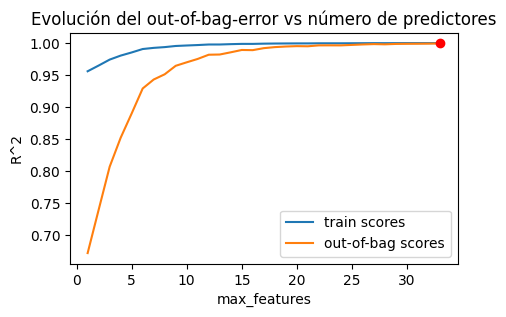

In [ ]:
# Validación empleando el Out-of-Bag error
# ==============================================================================
train_scores = []
oob_scores   = []

# Valores evaluados
max_features_range = range(1, x_train.shape[1] + 1, 1)

# Bucle para entrenar un modelo con cada valor de max_features y extraer su error
# de entrenamiento y de Out-of-Bag.
for max_features in max_features_range:
    modelo = RandomForestRegressor(
                n_estimators = 100,
                criterion    = 'squared_error',
                max_depth    = None,
                max_features = max_features,
                oob_score    = True,
                n_jobs       = -1,
                random_state = 123
             )
    modelo.fit(x_train, y_train)
    train_scores.append(modelo.score(x_train, y_train))
    oob_scores.append(modelo.oob_score_)

# Gráfico con la evolución de los errores
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(max_features_range, train_scores, label="train scores")
ax.plot(max_features_range, oob_scores, label="out-of-bag scores")
ax.plot(max_features_range[np.argmax(oob_scores)], max(oob_scores),
        marker='o', color = "red")
ax.set_ylabel("R^2")
ax.set_xlabel("max_features")
ax.set_title("Evolución del out-of-bag-error vs número de predictores")
plt.legend();
print(f"Valor óptimo de max_features: {max_features_range[np.argmax(oob_scores)]}")

Valor óptimo de max_features: 33


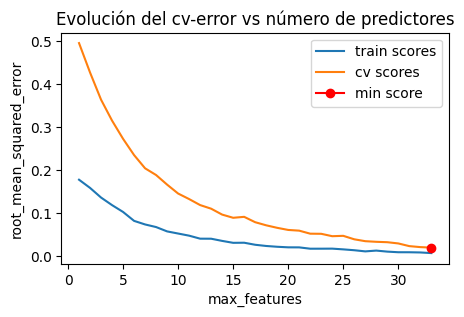

In [ ]:
# Validación empleando k-cross-validation y neg_root_mean_squared_error
# ==============================================================================
train_scores = []
cv_scores    = []

# Valores evaluados
max_features_range = range(1, x_train.shape[1] + 1, 1)

# Bucle para entrenar un modelo con cada valor de max_features y extraer su error
# de entrenamiento y de k-cross-validation.
for max_features in max_features_range:

    modelo = RandomForestRegressor(
                n_estimators = 100,
                criterion    = 'squared_error',
                max_depth    = None,
                max_features = max_features,
                oob_score    = True,
                n_jobs       = -1,
                random_state = 123
             )

    # Error de train
    modelo.fit(x_train, y_train)
    predicciones = modelo.predict(X = x_train)
    rmse = mean_squared_error(
            y_true  = y_train,
            y_pred  = predicciones,
            squared = False
           )
    train_scores.append(rmse)

    # Error de validación cruzada
    scores = cross_val_score(
                estimator = modelo,
                X         = x_train,
                y         = y_train,
                scoring   = 'neg_root_mean_squared_error',
                cv        = 5
             )
    # Se agregan los scores de cross_val_score() y se pasa a positivo
    cv_scores.append(-1*scores.mean())

# Gráfico con la evolución de los errores
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(max_features_range, train_scores, label="train scores")
ax.plot(max_features_range, cv_scores, label="cv scores")
ax.plot(max_features_range[np.argmin(cv_scores)], min(cv_scores),
        marker='o', color = "red", label="min score")
ax.set_ylabel("root_mean_squared_error")
ax.set_xlabel("max_features")
ax.set_title("Evolución del cv-error vs número de predictores")
plt.legend();
print(f"Valor óptimo de max_features: {max_features_range[np.argmin(cv_scores)]}")

Extras

In [ ]:
pd.concat([pd.DataFrame(grid_rf.cv_results_["params"]),
           pd.DataFrame(grid_rf.cv_results_["mean_test_score"],
                        columns=["neg_mean_absolute_error"])],axis=1).sort_values('neg_mean_absolute_error', ascending=False)

# NOTA: neg_mean_absolute_error mas cercano a 0 => mejor

,max_depth,max_features,n_estimators,neg_mean_absolute_error
0,10,33,100,-0.002508


In [ ]:
grid_rf.score(x_train, y_train)

-0.0006750723439515667

In [ ]:
grid_rf.score(x_test, y_test)

-0.004766942148768353

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


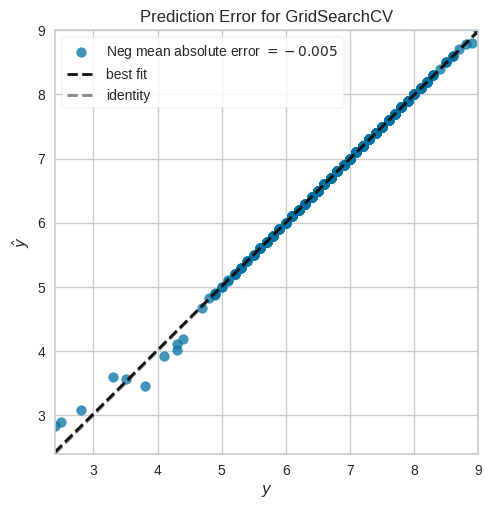

<Axes: title={'center': 'Prediction Error for GridSearchCV'}, xlabel='$y$', ylabel='$\\hat{y}$'>

In [ ]:
from yellowbrick.regressor import PredictionError

vis_pred_err = PredictionError(grid_rf)

vis_pred_err.fit(x_train, y_train)  # Fiteamos los datos al visualizador
vis_pred_err.score(x_test, y_test)  # Calculamos las métricas para test
vis_pred_err.show()                 # Visualizamos!

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


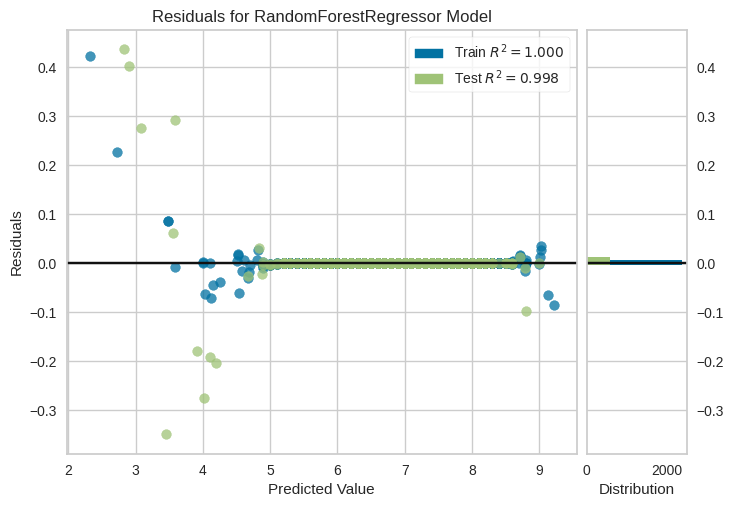

<Axes: title={'center': 'Residuals for RandomForestRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [ ]:
from yellowbrick.regressor import ResidualsPlot

# ojo: poner best_estimator_
vis_res = ResidualsPlot(grid_rf.best_estimator_)


# Copy-paste de la doc oficial:
vis_res.fit(x_train, y_train)  # Fiteamos los datos al visualizador
vis_res.score(x_test, y_test)  # Calculamos las métricas para test
vis_res.show()                 # Visualizamos!

Evaluamos los mejores hiperparametros


In [ ]:
# Grid de hiperparámetros evaluados
# ==============================================================================
param_grid = {'n_estimators': [100, 200, 300],
              'max_features': [32, 33],
              'max_depth'   : [None, 3, 10, 20, 30]
             }

# Búsqueda por grid search con validación cruzada
# ==============================================================================
grid = GridSearchCV(
            estimator  = RandomForestRegressor(random_state = 123),
            param_grid = param_grid,
            scoring    = 'neg_root_mean_squared_error',
            n_jobs     = multiprocessing.cpu_count() - 1,
            cv         = RepeatedKFold(n_splits=5, n_repeats=3, random_state=123),
            refit      = True,
            verbose    = 0,
            return_train_score = True
       )

grid.fit(X = x_train, y = y_train)

# Resultados
# ==============================================================================
resultados = pd.DataFrame(grid.cv_results_)
resultados.filter(regex = '(param.*|mean_t|std_t)') \
    .drop(columns = 'params') \
    .sort_values('mean_test_score', ascending = False) \
    .head(4)

,param_max_depth,param_max_features,param_n_estimators,mean_test_score,std_test_score,mean_train_score,std_train_score
15,10,33,100,-0.021504,0.015451,-0.010531,0.001823
3,None,33,100,-0.021601,0.015368,-0.010529,0.001813
27,30,33,100,-0.021601,0.015368,-0.010529,0.001813
21,20,33,100,-0.021601,0.015368,-0.010529,0.001813


In [ ]:
# Mejores hiperparámetros por validación cruzada
# ==============================================================================
print("----------------------------------------")
print("Mejores hiperparámetros encontrados (cv)")
print("----------------------------------------")
print(grid.best_params_, ":", grid.best_score_, grid.scoring)

----------------------------------------
Mejores hiperparámetros encontrados (cv)
----------------------------------------
{'max_depth': 10, 'max_features': 33, 'n_estimators': 100} : -0.021504307789338983 neg_root_mean_squared_error


In [ ]:
# Error de test del modelo final
# ==============================================================================
modelo_final = grid.best_estimator_
predicciones = modelo_final.predict(X = x_test)
rmse = mean_squared_error(
        y_true  = y_test,
        y_pred  = predicciones,
        squared = False
       )
print(f"El error (rmse) de test es: {rmse}")

El error (rmse) de test es: 0.017896026614727722


Pureza de los nodos

In [ ]:
importancia_predictores = pd.DataFrame({
                            'predictor': datos.drop(columns = ['Title','Popularity','Metascore']).columns,
                            'importancia': modelo_final.feature_importances_
                          })
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores.sort_values('importancia', ascending=False)

Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
0,Rating,9.987174e-01
3,Script2,4.656297e-04
7,Actor3,2.695168e-04
4,Script3,1.038308e-04
32,title,9.702809e-05
2,Script1,8.314828e-05
5,Actor1,5.884334e-05
6,Actor2,5.296385e-05
19,Ciencia,4.852818e-05
1,Direction,2.811609e-05


ValueError: ignored

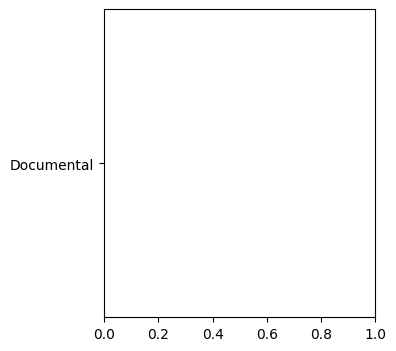

In [ ]:
# Código para graficar
# Gráfico
fig, ax = plt.subplots(figsize=(3.5, 4))
importancia_predictores = importancia_predictores.sort_values('importancia', ascending=True)
ax.barh(
    importancia_predictores['predictor'],  # Aquí ajusté el nombre
    importancia_predictores['importancia'],
    xerr=importancia_predictores['importancia'],
    align='center',
    alpha=0
)
ax.plot(
    importancia_predictores['importancia'],
    importancia_predictores['predictor'],  # Aquí ajusté el nombre
    marker="D",
    linestyle="",
    alpha=0.8,
    color="r"
)
ax.set_title('Importancia de los predictores (train)')
ax.set_xlabel('Incremento del error tras la permutación')

Resultados:

In [ ]:
predictions = modelo_final.predict(x_test)
pred = pd.DataFrame({'Actual': y_test.tolist(), 'Predicted': predictions.tolist()}).head(25)
pred.head(10)

,Actual,Predicted
0,6.5,6.5
1,7.1,7.1
2,6.2,6.2
3,7.3,7.3
4,6.8,6.8
5,6.7,6.7
6,8.1,8.1
7,7.2,7.2
8,7.0,7.0
9,7.4,7.4
